# Figure 3: cosine-DRAG sequences with finite leakage

Companion to **Universal $\pi/2$ composite pulses**, H. G. Tonchev, P. Chernev,
A. A. Rangelov, and N. V. Vitanov.

This notebook calculates the response of UVH1s and the palindromic
composite sequences UVH5s, UVH9s, and UVH13s to 16 ns cosine-DRAG
pulses with waveform coefficients
$I_0=0.2$ and $Q_0=-0.042$. Their ratio $q=Q_0/I_0=-0.21$ corresponds to
DRAG coefficient **1.68** for the assumed transmon anharmonicity of $-250$ MHz.
The contour figure retains two or five transmon levels. It has four
sequence rows and two level-model columns.

Each sequence begins in $|0\rangle$. The contours show the unconditional
population error $\Delta P=|P_1-1/2|$. A separate nominal-point calculation
reports leakage and state fidelity for two, three, and five levels. These
diagnostics distinguish half transfer from preparation of the ideal coherent
qubit state. The phase lists are fixed inputs.

Run all cells in order using Python 3.11 or newer with NumPy, SciPy,
Matplotlib, threadpoolctl, and Jupyter installed. The default calculation
may take around 20 minutes on a desktop CPU. Vector figures are saved in
`results/figure_3/`; numerical arrays,
previews, and calculation settings are written to
`results/figure_3/artifacts/iqm_drag/`.

In [1]:
import json
import platform
from pathlib import Path
from time import perf_counter

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FormatStrFormatter
from IPython.display import display, Markdown, Image
import numpy as np
import scipy
from scipy.integrate import solve_ivp
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import least_squares
from threadpoolctl import threadpool_limits


def show_table(rows):
    keys = list(rows[0])
    lines = ['| ' + ' | '.join(keys) + ' |',
             '| ' + ' | '.join(['---'] * len(keys)) + ' |']
    for row in rows:
        lines.append('| ' + ' | '.join(f'{row[k]:.7g}' if isinstance(row[k], float)
                                       else str(row[k]) for k in keys) + ' |')
    display(Markdown('\n'.join(lines)))


DURATION_NS = 16.0
I_COEFFICIENT = 0.2             # Waveform amplitudes in arbitrary units.
Q_COEFFICIENT = -0.042
Q_OVER_I = Q_COEFFICIENT / I_COEFFICIENT
T = np.pi                      # Dimensionless pulse duration.
ANHARMONICITY = -8.0            # In units of Omega_ref.
DRAG_COEFFICIENT = Q_OVER_I * ANHARMONICITY * T / np.pi
LEVEL_COUNTS = (2, 5)           # Full contour calculations.
NOMINAL_LEVEL_COUNTS = (2, 3, 5) # Additional three-level diagnostic at zero error.
GRID_SIZE = 401
PLOT_GRID_SIZE = 2401
BATCH_SIZE = 256
RTOL, ATOL = 2e-11, 2e-13

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / 'uvh_validation').is_dir() and (p / 'data/pulses.json').is_file())
OUTPUT_DIR = ROOT / 'results' / 'figure_3'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR = OUTPUT_DIR / 'artifacts' / 'iqm_drag'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
assert GRID_SIZE >= 5 and GRID_SIZE % 2 == 1
assert PLOT_GRID_SIZE >= GRID_SIZE and BATCH_SIZE > 0
show_table([dict(package='Python', version=platform.python_version()),
            dict(package='NumPy', version=np.__version__),
            dict(package='SciPy', version=scipy.__version__),
            dict(package='Matplotlib', version=matplotlib.__version__)])

| package | version |
| --- | --- |
| Python | 3.12.14 |
| NumPy | 2.4.2 |
| SciPy | 1.17.1 |
| Matplotlib | 3.10.8 |

## 1. Pulse shape and units

For physical time $0\leq t_{\rm p}\leq16$ ns, the waveform is
$$I_{\rm w}(t_{\rm p})=0.2\sin^2\!\left(\frac{\pi t_{\rm p}}{16\,\mathrm{ns}}\right),
\qquad Q_{\rm w}(t_{\rm p})=-0.042\sin\!\left(\frac{2\pi t_{\rm p}}{16\,\mathrm{ns}}\right).$$
The plot displays these continuous envelopes and 32 midpoint samples spaced
by 0.5 ns. Evolution uses the continuous functions, without a sample-and-hold
or filtering model. The first Q lobe is negative and the second is positive.

Set $\hbar=1$ and choose $t=\Omega_{\rm ref}t_{\rm p}$ with pulse duration
$T=\pi$. Thus $\Omega_{\rm ref}/(2\pi)=31.25$ MHz and dimensionless
anharmonicity $a=-8$ corresponds to $-250$ MHz. The dimensionless fields are
$$I(t)=\frac{\pi}{T}\sin^2(\pi t/T),\qquad
Q(t)=\frac{\pi}{T}q\sin(2\pi t/T),\qquad q=-0.21.$$
This normalization gives $\int_0^T I(t)\,dt=\pi/2$. It defines the model
frequency scale; the arbitrary waveform amplitudes alone do not determine
a measured hardware-to-Rabi-frequency conversion.

In the convention $Q=(\beta_{\rm D}/a)\,dI/dt$,
$$\beta_{\rm D}=q\,a\,T/\pi=1.68.$$
Both quadratures receive the same gain during calibration, preserving $q$.

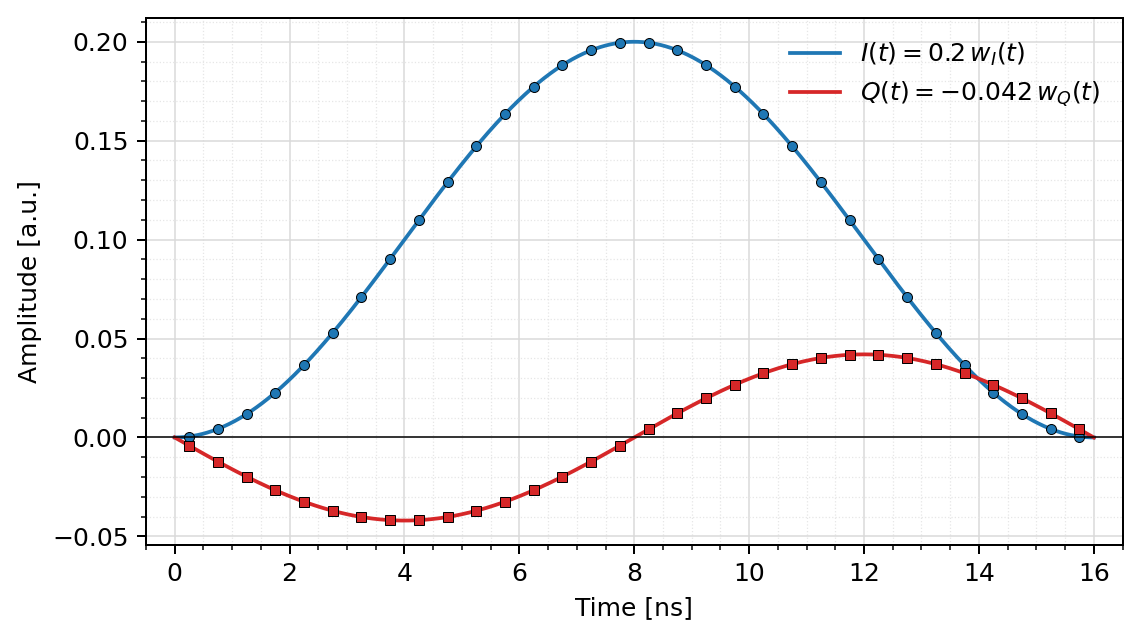

In [2]:
def envelopes(time):
    """Dimensionless I and Q during one pulse, 0 <= time <= T."""
    angle = np.pi * np.asarray(time) / T
    in_phase = (np.pi / T) * np.sin(angle)**2
    quadrature = (np.pi / T) * Q_OVER_I * np.sin(2 * angle)
    return in_phase, quadrature


def waveform(time_ns):
    """Uncalibrated waveform in arbitrary amplitude units."""
    in_phase, quadrature = envelopes(np.asarray(time_ns) * T / DURATION_NS)
    return I_COEFFICIENT * T / np.pi * in_phase, I_COEFFICIENT * T / np.pi * quadrature


time_ns = np.linspace(0, DURATION_NS, 1001)
sample_times_ns = (np.arange(32) + 0.5) * DURATION_NS / 32
in_phase, quadrature = waveform(time_ns)
sample_i, sample_q = waveform(sample_times_ns)
np.testing.assert_allclose(waveform([0, DURATION_NS]), 0, rtol=0, atol=1e-16)
np.testing.assert_allclose(waveform([4.0, 8.0, 12.0]),
                           [[0.1, 0.2, 0.1], [-0.042, 0.0, 0.042]], rtol=0, atol=1e-15)
pulse_path = OUTPUT_DIR / 'figure_3_iqm_pulse.pdf'
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(time_ns, in_phase, color='#1f77b4', label=r'$I(t)=0.2\,w_I(t)$')
ax.plot(time_ns, quadrature, color='#d62728', label=r'$Q(t)=-0.042\,w_Q(t)$')
ax.plot(sample_times_ns, sample_i, 'o', color='#1f77b4', markersize=4,
        markeredgecolor='black', markeredgewidth=0.4)
ax.plot(sample_times_ns, sample_q, 's', color='#d62728', markersize=4,
        markeredgecolor='black', markeredgewidth=0.4)
ax.axhline(0, color='black', linewidth=0.6)
ax.set(xlabel='Time [ns]', ylabel='Amplitude [a.u.]', xlim=(-0.5, 16.5))
ax.minorticks_on()
ax.grid(which='major', color='0.85', linewidth=0.6)
ax.grid(which='minor', color='0.9', linestyle=':', linewidth=0.5)
ax.legend(frameon=False)
fig.savefig(pulse_path, bbox_inches='tight', metadata={'CreationDate': None, 'ModDate': None})
fig.savefig(ARTIFACT_DIR / 'pulse.png', dpi=180, bbox_inches='tight')
display(Image(filename=str(ARTIFACT_DIR / 'pulse.png')))
plt.close(fig)

## 2. Integrate the Schrödinger equation

For $L$ transmon levels, define $N_{nn}=n$ and $b_{n,n+1}=\sqrt{n+1}$,
with $n=0,\ldots,L-1$. The rotating-frame Hamiltonian is
$$H(t)=-dN+\frac{a}{2}N(N-1)+c(t)b+c(t)^*b^\dagger,
\qquad c(t)=s\frac{I(t)+iQ(t)}{2}e^{i\phi}.$$
Here $d=(\omega_{\rm drive}-\omega_{01})/\Omega_{\rm ref}$ and $s$ is
the amplitude scale. The five-level diagonal is
$(0,-d,-2d+a,-3d+3a,-4d+6a)$. The upper off-diagonal contains $e^{+i\phi}$.

Solve $\dot U=-iHU$, with $U(0)=\mathbb{1}$, using SciPy's adaptive
eighth-order DOP853 method in double-precision complex arithmetic. Every
matrix entry is propagated. The leading array dimension groups independent
parameter points; it does not couple their physics. `solve_ivp` requires a
flat vector, so reshaping occurs only at its interface. Later checks compare
tighter tolerances and individual-point solves with the batched calculation.

In [3]:
def primitive_propagators(detuning, amplitude, levels, phase=0.0,
                          rtol=RTOL, atol=ATOL):
    """Return U(T) for each pair of raw detuning/amplitude controls."""
    detuning, amplitude = np.broadcast_arrays(detuning, amplitude)
    detuning, amplitude = detuning.ravel(), amplitude.ravel()
    count = len(detuning)
    n = np.arange(levels)
    lowering = np.diag(np.sqrt(n[1:]), k=1)
    energies = -detuning[:, None] * n + ANHARMONICITY * n * (n - 1) / 2
    drift = energies[:, :, None] * np.eye(levels)

    def rhs(time, flat_unitary):
        unitary = flat_unitary.reshape(count, levels, levels)
        in_phase, quadrature = envelopes(time)
        drive = amplitude * (in_phase + 1j * quadrature) * np.exp(1j * phase) / 2
        hamiltonian = (drift
                       + drive[:, None, None] * lowering
                       + drive.conj()[:, None, None] * lowering.T)
        return (-1j * (hamiltonian @ unitary)).ravel()

    identity = np.broadcast_to(np.eye(levels, dtype=complex), (count, levels, levels))
    # Multithreaded BLAS overhead is costly for these tiny matrices.
    with threadpool_limits(limits=1, user_api='blas'):
        solution = solve_ivp(rhs, (0, T), identity.ravel(), method='DOP853',
                             rtol=rtol, atol=atol, t_eval=[T])
    if not solution.success:
        raise RuntimeError(solution.message)
    return solution.y[:, -1].reshape(count, levels, levels)


# With the drive off, the solution is diagonal free evolution.
for levels in NOMINAL_LEVEL_COUNTS:
    n = np.arange(levels)
    energies = -0.137 * n + ANHARMONICITY * n * (n - 1) / 2
    exact = np.diag(np.exp(-1j * T * energies))
    numerical = primitive_propagators(0.137, 0.0, levels)[0]
    np.testing.assert_allclose(numerical, exact, rtol=0, atol=2e-8)

## 3. Calibrate one nominal $\pi/2$ primitive per level model

For each level model, solve for an amplitude gain $\kappa$ and a static
carrier offset $d_{\rm cal}$ such that
$$|U_{10}|^2=\frac12,\qquad
\alpha=\frac12\arg(U_{00}U_{11}^*)=0.$$
All sequences within a model reuse this one calibration. Both I and Q receive
the gain; their ratio, the pulse duration, anharmonicity, and phase lists are
fixed. The waveform plot shows the coefficients before this gain is applied.

Define $x=\Delta/\Omega_0$ and $r=\Omega/\Omega_0$, where
$\Omega_0/\Omega_{\rm ref}=\kappa\pi/T$. The Hamiltonian controls are
$$d=d_{\rm cal}+(\kappa\pi/T)x,\qquad s=\kappa r.$$
**Zero control error is $(x,r)=(0,1)$ on the contour axes.** In fractional
amplitude-error coordinates $\eta=r-1$, it is $(x,\eta)=(0,0)$.

Calibration fixes the primitive's unconditional $P_1$ and diagonal phase.
It does not eliminate population in higher levels or turn a multilevel
propagator into an exact two-level rotation. Consequently composite
sequences can have nonzero nominal population error and state infidelity.

In [4]:
def calibration_residual(unitary):
    population_error = abs(unitary[1, 0])**2 - 0.5
    phase_error = np.angle(unitary[0, 0] * unitary[1, 1].conj()) / 2
    return np.array([population_error, phase_error])


def calibrate(levels):
    def residual(controls):
        gain, offset = controls
        unitary = primitive_propagators(offset, gain, levels, rtol=2e-12, atol=2e-14)[0]
        return calibration_residual(unitary)

    fit = least_squares(residual, [1.0, 0.0], jac='3-point',
                        bounds=([0.5, -1.0], [1.5, 1.0]),
                        ftol=1e-13, xtol=1e-13, gtol=1e-13, max_nfev=50)
    assert fit.success and np.max(abs(residual(fit.x))) < 5e-12
    return dict(gain=float(fit.x[0]), offset=float(fit.x[1]))


calibrations = {levels: calibrate(levels) for levels in NOMINAL_LEVEL_COUNTS}
show_table([dict(levels=levels, amplitude_gain=calibration['gain'],
                 carrier_offset_over_Omega_ref=calibration['offset'])
            for levels, calibration in calibrations.items()])


def calibrated_propagators(x, ratio, levels, **solver_options):
    gain = calibrations[levels]['gain']
    offset = calibrations[levels]['offset']
    detuning = offset + gain * (np.pi / T) * np.asarray(x)
    amplitude = gain * np.asarray(ratio)
    return primitive_propagators(detuning, amplitude, levels, **solver_options)

| levels | amplitude_gain | carrier_offset_over_Omega_ref |
| --- | --- | --- |
| 2 | 0.9960007 | -0.08818338 |
| 3 | 0.9954003 | -0.06166625 |
| 5 | 0.9954071 | -0.06159255 |

## 4. Composite phases and coherent pulse products

The phases are in radians and chronological order. Each sequence is
palindromic: specify its first half including the center, then reflect it.
The phase vectors satisfy the universal cancellation conditions through
orders 0, 1, 2, and 3 for UVH1s, UVH5s, UVH9s, and UVH13s, respectively.
Retain their displayed precision for the $10^{-6}$ contours.

Phase covariance gives
$$U_\phi=D_\phi U_0D_\phi^\dagger,\qquad
D_\phi=\operatorname{diag}(e^{-in\phi}).$$
Integrate one phase-zero primitive per parameter point, then apply its
phased copies successively to $|0\rangle$. All levels remain coherent
between contiguous pulses in a common drive frame. There is no projection,
renormalization, decoherence, or additional frequency chirp.

In [5]:
half_phases = {
    'UVH1s': [0.0],
    'UVH5s': [0.0, 2.4036953395695386, 2.800696140217786],
    'UVH9s': [0.0, 0.07171482964187637, 2.9557152622255125,
              2.888019137232617, 1.3987467053767204],
    'UVH13s': [0.0, 0.8547851026602972, 1.1810531761877006,
               4.131669079745312, 3.857526528619011, 2.3080244474724627,
               2.554634499291114],
}
phases = {name: np.array(half + half[-2::-1]) for name, half in half_phases.items()}
sequence_names = tuple(phases)
plot_names = ('UVH1s', 'UVH5s', 'UVH9s', 'UVH13s')
show_table([dict(sequence=name, pulses=len(p), cancelled_order=order)
            for order, (name, p) in enumerate(phases.items())])


def sequence_state(unitary, pulse_phases):
    """Apply U_phi in chronological order, starting in |0>."""
    levels = unitary.shape[-1]
    state = np.zeros(unitary.shape[:-1], dtype=complex)
    state[..., 0] = 1.0
    for phase in pulse_phases:
        rotation = np.diag(np.exp(-1j * np.arange(levels) * phase))
        phased_unitary = rotation @ unitary @ rotation.conj().T
        state = (phased_unitary @ state[..., None])[..., 0]
    return state


# An asymmetric phase list checks the phase sign and chronological order.
phase_check = {}
for levels in NOMINAL_LEVEL_COUNTS:
    test_phases = [0.13, -0.82, 0.41]
    unitary = calibrated_propagators(0.137, 1.073, levels)
    cached = sequence_state(unitary, test_phases)[0]
    direct = np.eye(levels, dtype=complex)[:, 0]
    for phase in test_phases:
        direct = calibrated_propagators(0.137, 1.073, levels, phase=phase)[0] @ direct
    phase_check[levels] = float(np.max(abs(cached - direct)))
    assert phase_check[levels] < 2e-10

| sequence | pulses | cancelled_order |
| --- | --- | --- |
| UVH1s | 1 | 0 |
| UVH5s | 5 | 1 |
| UVH9s | 9 | 2 |
| UVH13s | 13 | 3 |

### Nominal-point leakage and state fidelity

At $(x,\eta)=(0,0)$, calculate the full final state of each sequence.
Report three distinct quantities:

* Population error: $\Delta P=|P_1-1/2|$, with $P_1=|\psi_1|^2$.
* Leakage: $L=\sum_{n=2}^{N_{\rm levels}-1}|\psi_n|^2$.
* State fidelity: $F_{\rm state}=|\langle\psi_{\rm ideal}|\psi\rangle|^2$,
  where $|\psi_{\rm ideal}\rangle$ is obtained from the **same phase list**
  using perfect two-level $R_x(\pi/2)$ primitives.

The ideal state is embedded in the full Hilbert space with zero amplitudes
above level 1. Fidelity is unconditional, so leakage reduces it. This is
state-preparation fidelity for initial $|0\rangle$, not average gate fidelity.
The contour plots below use $\Delta P$, which can be small even when leakage
and state infidelity are larger.

The three-level calculation is included here to resolve the effect of adding
the first noncomputational state. Tighter integrations check that the nominal
residuals are resolved numerically. Physical residuals are neither subtracted
nor forced to zero.

In [6]:
ideal_primitive = np.array([[1, -1j], [-1j, 1]]) / np.sqrt(2)
ideal_states = np.array([sequence_state(ideal_primitive[None], p)[0] for p in phases.values()])
np.testing.assert_allclose(abs(ideal_states[:, 1])**2, 0.5, rtol=0, atol=2e-12)
nominal_rows, nominal_checks = [], {}
nominal_propagators, nominal_states = {}, {}

for levels in NOMINAL_LEVEL_COUNTS:
    unitary = calibrated_propagators(0.0, 1.0, levels, rtol=1e-12, atol=1e-14)
    tighter = calibrated_propagators(0.0, 1.0, levels, rtol=2e-13, atol=2e-15)
    states = np.array([sequence_state(unitary, p)[0] for p in phases.values()])
    tight_states = np.array([sequence_state(tighter, p)[0] for p in phases.values()])
    population_change = float(np.max(abs(abs(states)**2 - abs(tight_states)**2)))
    norm_defect = float(np.max(abs((abs(states)**2).sum(axis=1) - 1)))
    residual = float(np.max(abs(calibration_residual(unitary[0]))))
    assert population_change < 2e-9 and norm_defect < 2e-9 and residual < 5e-12
    nominal_propagators[levels], nominal_states[levels] = unitary[0], states
    nominal_checks[levels] = dict(max_population_change=population_change,
                                 max_norm_defect=norm_defect, calibration_residual=residual,
                                 max_phase_covariance_error=phase_check[levels])
    for index, name in enumerate(sequence_names):
        population = abs(states[index])**2
        leakage = float(population[2:].sum())
        fidelity = float(abs(np.vdot(ideal_states[index], states[index, :2]))**2)
        assert 0 <= fidelity <= 1 + 2e-9 and fidelity + leakage <= 1 + 2e-9
        nominal_rows.append(dict(levels=levels, sequence=name, P1=float(population[1]),
                                 population_error=float(abs(population[1] - 0.5)),
                                 leakage=leakage, state_fidelity=fidelity))
show_table(nominal_rows)
show_table([dict(levels=levels, **checks) for levels, checks in nominal_checks.items()])

| levels | sequence | P1 | population_error | leakage | state_fidelity |
| --- | --- | --- | --- | --- | --- |
| 2 | UVH1s | 0.5 | 2.320366e-14 | 0 | 1 |
| 2 | UVH5s | 0.5 | 1.901812e-13 | 0 | 1 |
| 2 | UVH9s | 0.5 | 4.356515e-13 | 0 | 1 |
| 2 | UVH13s | 0.5 | 6.291634e-13 | 0 | 1 |
| 3 | UVH1s | 0.5 | 5.551115e-16 | 2.031805e-06 | 0.999998 |
| 3 | UVH5s | 0.4999991 | 8.969005e-07 | 2.126281e-05 | 0.9999787 |
| 3 | UVH9s | 0.4999753 | 2.473421e-05 | 3.976803e-05 | 0.9999602 |
| 3 | UVH13s | 0.4999816 | 1.843257e-05 | 2.023114e-05 | 0.9999798 |
| 5 | UVH1s | 0.5 | 3.330669e-16 | 2.012701e-06 | 0.999998 |
| 5 | UVH5s | 0.4999991 | 8.897847e-07 | 2.015734e-05 | 0.9999798 |
| 5 | UVH9s | 0.4999717 | 2.830277e-05 | 3.847752e-05 | 0.9999615 |
| 5 | UVH13s | 0.4999829 | 1.708746e-05 | 1.826379e-05 | 0.9999817 |

| levels | max_population_change | max_norm_defect | calibration_residual | max_phase_covariance_error |
| --- | --- | --- | --- | --- |
| 2 | 4.936052e-13 | 1.251665e-12 | 4.278522e-14 | 9.155134e-16 |
| 3 | 1.110223e-15 | 3.996803e-15 | 6.661338e-16 | 1.20089e-15 |
| 5 | 5.939693e-15 | 6.77236e-15 | 3.330669e-16 | 1.890642e-15 |

## 5. Sweep the two plotted coordinates

A $401\times401$ grid covers $-0.2\leq\Delta/\Omega_0\leq0.2$ and
$0.8\leq\Omega/\Omega_0\leq1.2$. Store all final level populations in
arrays ordered `[sequence, amplitude index, detuning index, level]`. The
four sequences appear in the contour figure.

Every batch checks primitive unitarity and final probability conservation.
Increasing `GRID_SIZE` refines the spatial sampling; runtime grows
approximately with its square. No population is conditioned on remaining
in the computational subspace.

In [7]:
detuning_axis = np.linspace(-0.2, 0.2, GRID_SIZE)
amplitude_axis = np.linspace(0.8, 1.2, GRID_SIZE)
x_grid, ratio_grid = np.meshgrid(detuning_axis, amplitude_axis)
x_points, ratio_points = x_grid.ravel(), ratio_grid.ravel()
populations, sweep_checks = {}, {}

for levels in LEVEL_COUNTS:
    started = perf_counter()
    values = np.empty((len(phases), len(x_points), levels))
    max_unitarity = max_norm_defect = 0.0
    for start in range(0, len(x_points), BATCH_SIZE):
        stop = min(start + BATCH_SIZE, len(x_points))
        unitary = calibrated_propagators(x_points[start:stop], ratio_points[start:stop], levels)
        defect = unitary.conj().swapaxes(-1, -2) @ unitary - np.eye(levels)
        max_unitarity = max(max_unitarity, float(np.max(abs(defect))))
        for index, pulse_phases in enumerate(phases.values()):
            population = abs(sequence_state(unitary, pulse_phases))**2
            values[index, start:stop] = population
            max_norm_defect = max(max_norm_defect, float(np.max(abs(population.sum(axis=1) - 1))))
    assert np.all(np.isfinite(values))
    assert max_unitarity < 2e-9 and max_norm_defect < 2e-9
    populations[levels] = values.reshape(len(phases), GRID_SIZE, GRID_SIZE, levels)
    center_populations = populations[levels][:, GRID_SIZE // 2, GRID_SIZE // 2]
    np.testing.assert_allclose(center_populations, abs(nominal_states[levels])**2, rtol=0, atol=2e-9)
    sweep_checks[levels] = dict(seconds=perf_counter() - started,
                                max_unitarity_defect=max_unitarity, max_norm_defect=max_norm_defect)
    show_table([dict(levels=levels, grid_points=len(x_points), **sweep_checks[levels])])

| levels | grid_points | seconds | max_unitarity_defect | max_norm_defect |
| --- | --- | --- | --- | --- |
| 2 | 160801 | 17.80539 | 1.201483e-12 | 1.515854e-11 |

| levels | grid_points | seconds | max_unitarity_defect | max_norm_defect |
| --- | --- | --- | --- | --- |
| 5 | 160801 | 1050.2 | 2.238265e-10 | 5.906386e-14 |

## 6. Check time integration and interpolation

Use 25 points spanning the corners, edges, axes, and center; 8 seeded random
points; and 256 off-grid cell midpoints, half concentrated near nominal
controls. At these 289 points, tighten DOP853 tolerances from
$(2\times10^{-11},2\times10^{-13})$ to $(10^{-12},10^{-14})$ and compare
complex propagators, final states, and all level populations. Individual
solves at the four corners and center additionally check batching.

Interpolate the **signed** residual $P_1-1/2$. Taking its absolute value
first creates a cusp and can erase narrow low-error bands. Fresh integrations
at the off-grid points test the bicubic interpolant. The allowed absolute
interpolation error is $5\times10^{-9}$, or 0.5% of the smallest contour.

In [8]:
check_x, check_ratio = np.meshgrid(np.linspace(-0.2, 0.2, 5), np.linspace(0.8, 1.2, 5))
random_points = np.random.default_rng(20260914).uniform([-0.2, 0.8], [0.2, 1.2], (8, 2))
rng = np.random.default_rng(20260915)
cells = rng.integers(0, GRID_SIZE - 1, size=(256, 2))
center, radius = (GRID_SIZE - 1) // 2, max(2, GRID_SIZE // 40)
cells[:128] = rng.integers(center - radius, center + radius, size=(128, 2))
off_grid = np.column_stack([
    (detuning_axis[cells[:, 0]] + detuning_axis[cells[:, 0] + 1]) / 2,
    (amplitude_axis[cells[:, 1]] + amplitude_axis[cells[:, 1] + 1]) / 2,
])
check_points = np.vstack([np.column_stack([check_x.ravel(), check_ratio.ravel()]),
                          random_points, off_grid])
check_propagators, check_states, accuracy_checks, splines = {}, {}, {}, {}

for levels in LEVEL_COUNTS:
    ordinary = calibrated_propagators(*check_points.T, levels)
    tighter = calibrated_propagators(*check_points.T, levels, rtol=1e-12, atol=1e-14)
    states = np.array([sequence_state(ordinary, p) for p in phases.values()])
    tight_states = np.array([sequence_state(tighter, p) for p in phases.values()])
    single_error = 0.0
    for index in (0, 4, 12, 20, 24):
        single = calibrated_propagators(*check_points[index], levels, rtol=1e-12, atol=1e-14)[0]
        single_error = max(single_error, float(np.max(abs(single - ordinary[index]))))
    splines[levels] = [RectBivariateSpline(amplitude_axis, detuning_axis, p[:, :, 1] - 0.5)
                       for p in populations[levels]]
    interpolation_errors = []
    for index, spline in enumerate(splines[levels]):
        interpolated = spline.ev(off_grid[:, 1], off_grid[:, 0])
        direct = abs(tight_states[index, 33:, 1])**2 - 0.5
        interpolation_errors.append(float(np.max(abs(interpolated - direct))))
    checks = dict(
        max_propagator_change=float(np.max(abs(ordinary - tighter))),
        max_state_change=float(np.max(abs(states - tight_states))),
        max_population_change=float(np.max(abs(abs(states)**2 - abs(tight_states)**2))),
        max_single_point_change=single_error,
        max_phase_covariance_error=phase_check[levels],
        interpolation_error_by_sequence=dict(zip(sequence_names, interpolation_errors)),
    )
    assert checks['max_propagator_change'] < 2e-8 and single_error < 2e-8
    assert checks['max_state_change'] < 2e-9 and checks['max_population_change'] < 2e-9
    assert max(interpolation_errors) < 5e-9, 'Increase GRID_SIZE for accurate contours.'
    check_propagators[levels], check_states[levels] = ordinary, states
    accuracy_checks[levels] = checks

show_table([dict(levels=levels, check=name, max_error=value)
            for levels, checks in accuracy_checks.items()
            for name, value in checks.items() if name != 'interpolation_error_by_sequence'])
show_table([dict(levels=levels, sequence=name, interpolation_error=error)
            for levels, checks in accuracy_checks.items()
            for name, error in checks['interpolation_error_by_sequence'].items()])

| levels | check | max_error |
| --- | --- | --- |
| 2 | max_propagator_change | 2.646712e-12 |
| 2 | max_state_change | 1.742814e-11 |
| 2 | max_population_change | 2.870315e-12 |
| 2 | max_single_point_change | 2.715511e-12 |
| 2 | max_phase_covariance_error | 9.155134e-16 |
| 5 | max_propagator_change | 8.876025e-10 |
| 5 | max_state_change | 2.152895e-14 |
| 5 | max_population_change | 3.030909e-14 |
| 5 | max_single_point_change | 8.938311e-10 |
| 5 | max_phase_covariance_error | 1.890642e-15 |

| levels | sequence | interpolation_error |
| --- | --- | --- |
| 2 | UVH1s | 1.521075e-12 |
| 2 | UVH5s | 5.017955e-11 |
| 2 | UVH9s | 1.246064e-10 |
| 2 | UVH13s | 1.799e-10 |
| 5 | UVH1s | 7.369105e-15 |
| 5 | UVH5s | 5.188519e-11 |
| 5 | UVH9s | 1.816251e-10 |
| 5 | UVH13s | 1.624878e-10 |

## 7. Two- and five-level population-error contours

The rows are UVH1s, UVH5s, UVH9s, and UVH13s, with two levels on the left
and five levels on the right. Draw both signed contours
$P_1-1/2=\pm10^{-k}$, $k=1,\ldots,6$, on a $2401\times2401$ plotting
grid. The color of each positive/negative pair is shared.

The nominal point is $(\Delta/\Omega_0,\Omega/\Omega_0)=(0,1)$.
The finite nominal residuals of the multilevel sequences remain in the
landscape; no offset is subtracted from the plotted probabilities.

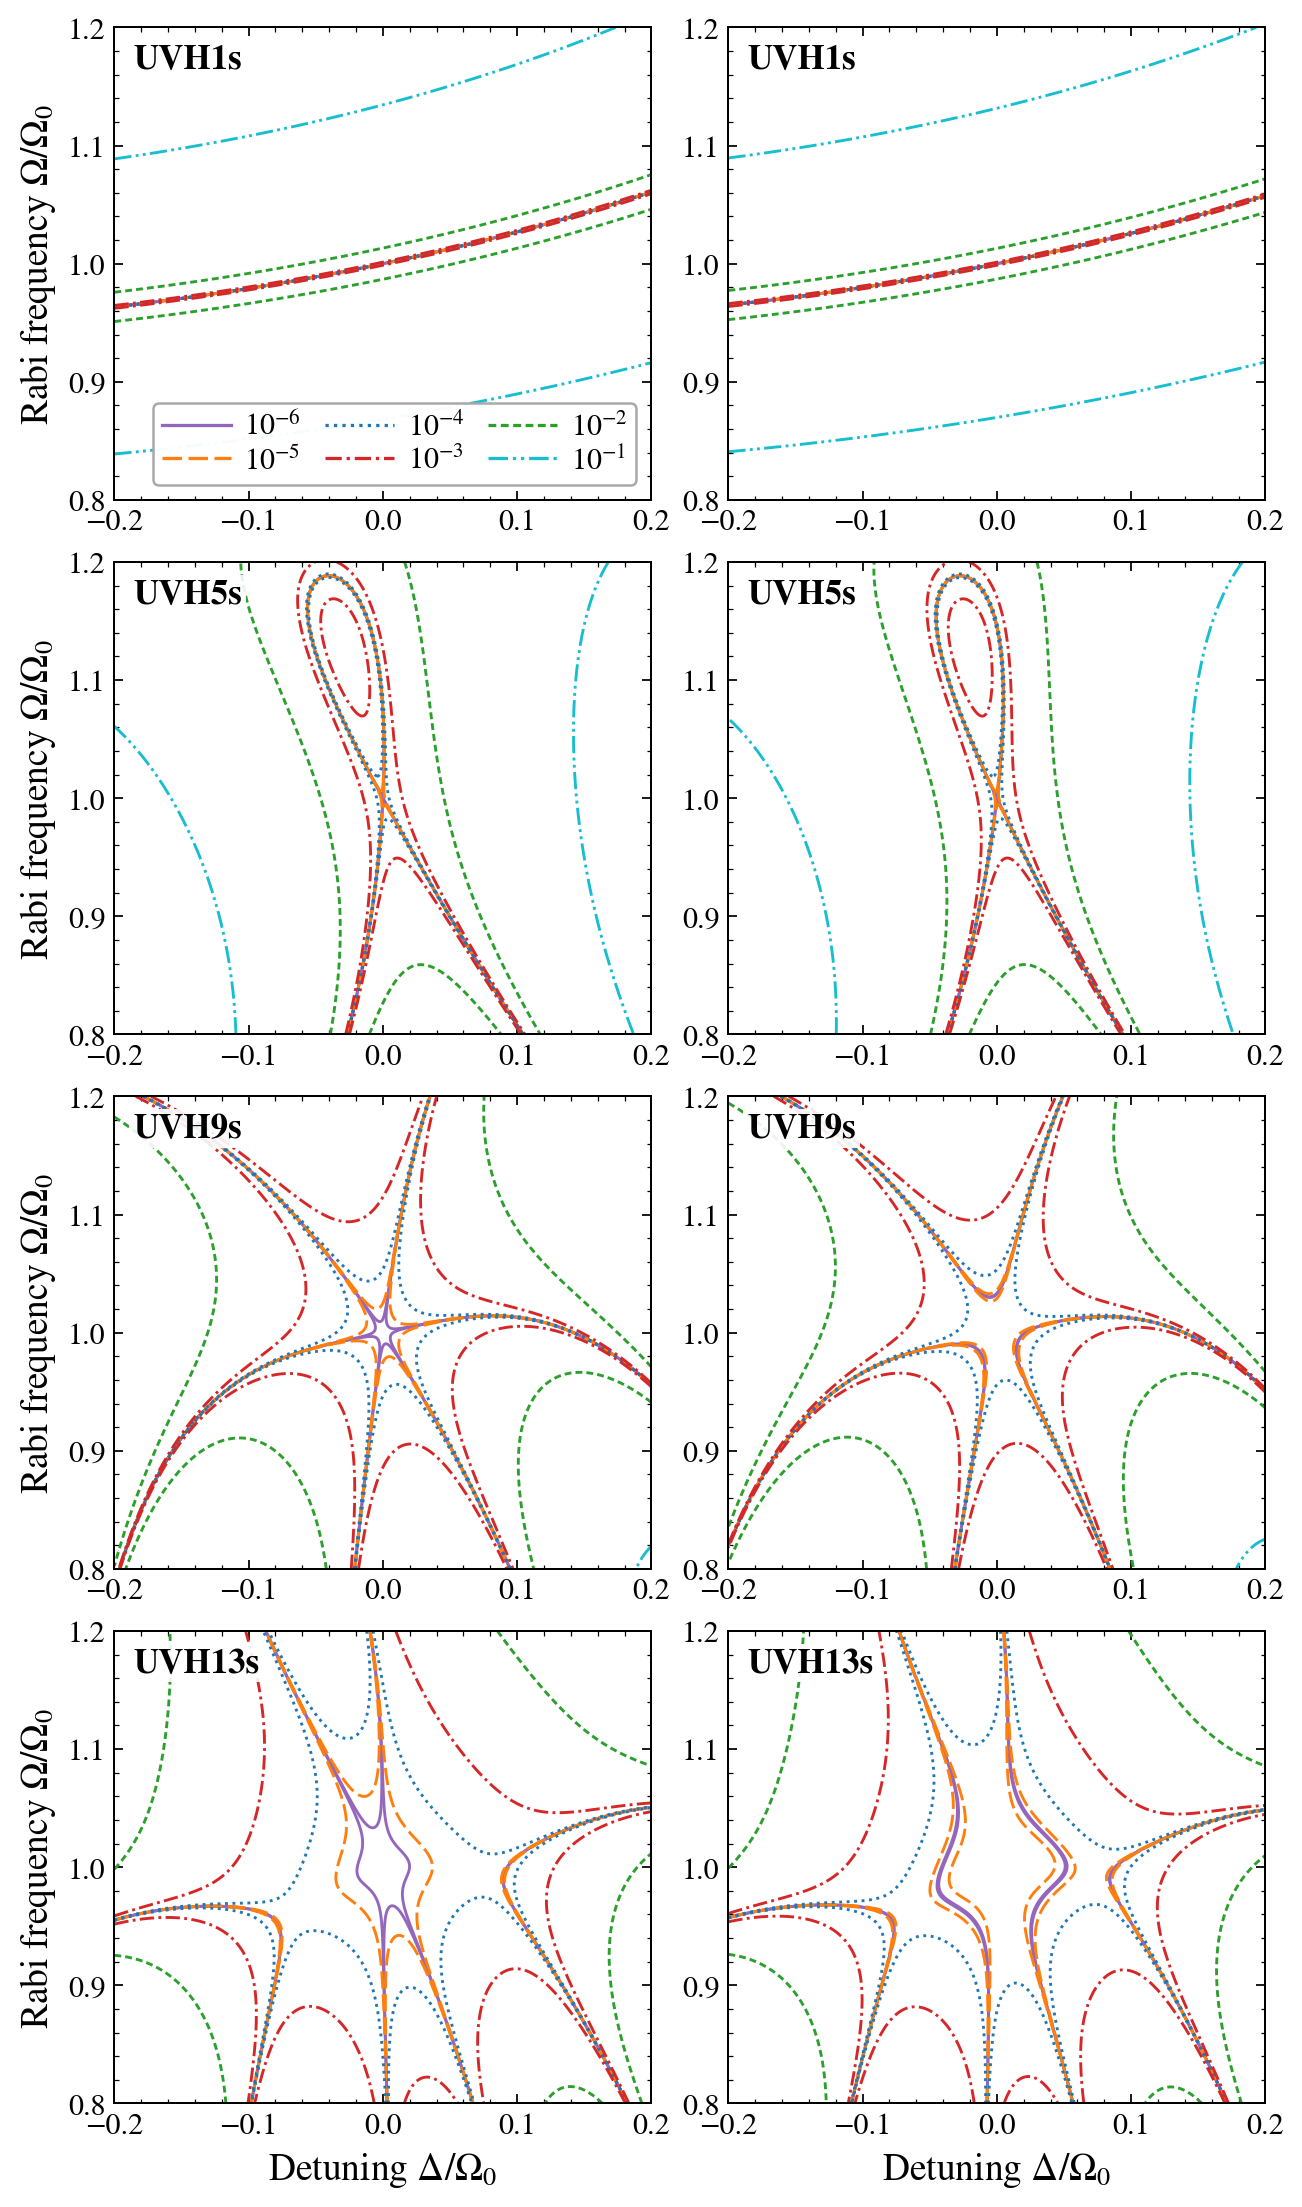

In [9]:
contour_levels = np.logspace(-6, -1, 6)
colors = ("#9467bd", "#ff7f0e","#1f77b4", "#d62728", "#2ca02c", "#17becf")
linestyles = (
    "solid",
    (0, (6, 2)),
    (0, (1, 1.6)),
    (0, (5, 1.5, 1, 1.5)),
    (0, (2.4, 1.4)),
    (0, (6, 1.5, 1, 1.5, 1, 1.5)),
)
fine_x = np.linspace(-0.2, 0.2, PLOT_GRID_SIZE)
fine_ratio = np.linspace(0.8, 1.2, PLOT_GRID_SIZE)
plot_style = {
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}
figure_path = OUTPUT_DIR / "figure_3_iqm_two_vs_five_level_drag.pdf"
preview_path = ARTIFACT_DIR / "figure_3.png"

if len(LEVEL_COUNTS) != 2 or len(plot_names) == 0:
    raise ValueError("Expected two level counts and at least one plot name")

with plt.rc_context(plot_style):
    fig, axes = plt.subplots(
        len(plot_names), 2, squeeze=False, sharex=True, sharey=True,
        figsize=(7.1, 2.95 * len(plot_names) + 0.35), layout="constrained",
    )
    try:
        for column, levels in enumerate(LEVEL_COUNTS):
            for row, name in enumerate(plot_names):
                ax = axes[row, column]
                index = sequence_names.index(name)
                signed_error = np.asarray(splines[levels][index](fine_ratio, fine_x))
                if signed_error.shape != (len(fine_ratio), len(fine_x)):
                    raise ValueError(f"{name}: residual grid has shape {signed_error.shape}")
                if not np.isfinite(signed_error).all():
                    raise ValueError(f"{name}: residual grid has nonfinite values")

                low, high = np.min(signed_error), np.max(signed_error)
                for level, color, dash in zip(contour_levels, colors, linestyles, strict=True):
                    # Keep both signs to preserve thin bands around zero crossings.
                    signed = [v for v in (-level, level) if low < v < high]
                    if signed:
                        ax.contour(
                            fine_x, fine_ratio, signed_error, levels=signed,
                            colors=[color], linestyles=[dash], linewidths=1.15,
                        )

                ax.text(
                    0.035, 0.965, name, transform=ax.transAxes,
                    va="top", ha="left", fontsize=14.0, fontweight="semibold",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5),
                )
                ax.set(
                    xlim=(-0.2, 0.2), ylim=(0.8, 1.2),
                    xticks=np.linspace(-0.2, 0.2, 5), yticks=np.linspace(0.8, 1.2, 5),
                )
                ax.set_box_aspect(0.88)
                ax.minorticks_on()
                ax.tick_params(
                    which="major", direction="in", top=True, right=True,
                    labelbottom=True, labelleft=True, labelsize=12, length=3.5, width=0.7,
                )
                ax.tick_params(
                    which="minor", direction="in", top=True, right=True,
                    length=1.8, width=0.5,
                )

        for ax in axes[:, 0]:
            ax.set_ylabel(r"Rabi frequency $\Omega/\Omega_0$", fontsize=15.0)
        for ax in axes[-1, :]:
            ax.set_xlabel(r"Detuning $\Delta/\Omega_0$", fontsize=15)

        handles = [
            Line2D([], [], color=color, linestyle=dash, linewidth=1.3,
                   label=rf"$10^{{{int(np.log10(level))}}}$")
            for level, color, dash in zip(contour_levels, colors, linestyles, strict=True)
        ]
        axes.flat[0].legend(
            handles=handles, loc="lower right", ncol=3,
            fontsize=12.0, title_fontsize=1.0,
            handlelength=2.3, handletextpad=0.45, columnspacing=0.8,
            labelspacing=0.15, borderpad=0.3, frameon=True,
            facecolor="white", edgecolor=".65", framealpha=0.97,
        )
        fig.savefig(figure_path, bbox_inches="tight", metadata={
            "Title": "Cosine-DRAG sequences with Q/I = -0.21",
            "Subject": json.dumps(dict(
                q_over_i=Q_OVER_I, drag=DRAG_COEFFICIENT, grid=GRID_SIZE,
                plot_grid=PLOT_GRID_SIZE, calibrations=calibrations,
            )),
            "CreationDate": None, "ModDate": None,
        })
        fig.savefig(preview_path, dpi=180, bbox_inches="tight")
        display(Image(filename=str(preview_path)))
    finally:
        plt.close(fig)

## 8. Save figure data and calculation settings

The archive contains the two- and five-level population grids, propagators
and states at the 289 accuracy-check points, the 32 waveform samples, and
nominal propagators and states for two, three, and five levels. The population
arrays use order `[sequence, amplitude, detuning, level]`, with sequence order
UVH1s, UVH5s, UVH9s, UVH13s.

Settings include the I/Q coefficients, normalization, phases, calibration,
solver tolerances, package versions, and accuracy checks. The nominal table
is saved with full numerical precision in the JSON report. Use
`np.load(path, allow_pickle=False)` to read the array archive.

In [10]:
metadata = dict(
    model=dict(duration_ns=DURATION_NS, duration=T, anharmonicity=ANHARMONICITY,
               i_coefficient=I_COEFFICIENT, q_coefficient=Q_COEFFICIENT,
               q_over_i=Q_OVER_I, drag=DRAG_COEFFICIENT, levels=list(LEVEL_COUNTS),
               nominal_levels=list(NOMINAL_LEVEL_COUNTS)),
    grid=GRID_SIZE, plot_grid=PLOT_GRID_SIZE, batch_size=BATCH_SIZE, rtol=RTOL, atol=ATOL,
    sequence_names=sequence_names, plot_names=plot_names,
    phases_rad={name: p.tolist() for name, p in phases.items()},
    calibrations=calibrations, sweep_checks=sweep_checks, accuracy_checks=accuracy_checks,
    nominal_results=nominal_rows, nominal_checks=nominal_checks,
    state_fidelity_definition='Squared overlap with the same phase sequence of ideal Rx(pi/2) pulses acting on |0>; no renormalization',
    versions=dict(python=platform.python_version(), numpy=np.__version__,
                  scipy=scipy.__version__, matplotlib=matplotlib.__version__),
)
arrays = dict(detuning_axis=detuning_axis, amplitude_axis=amplitude_axis,
              check_points=check_points, ideal_states=ideal_states,
              sample_times_ns=sample_times_ns, sample_i=sample_i, sample_q=sample_q,
              metadata=np.array(json.dumps(metadata)))
for levels in LEVEL_COUNTS:
    arrays[f'populations_{levels}'] = populations[levels]
    arrays[f'check_propagators_{levels}'] = check_propagators[levels]
    arrays[f'check_states_{levels}'] = check_states[levels]
for levels in NOMINAL_LEVEL_COUNTS:
    arrays[f'nominal_propagators_{levels}'] = nominal_propagators[levels]
    arrays[f'nominal_states_{levels}'] = nominal_states[levels]
np.savez_compressed(ARTIFACT_DIR / 'figure_3_data.npz', **arrays)
(ARTIFACT_DIR / 'run.json').write_text(json.dumps(metadata, indent=2) + '\n')
show_table([
    dict(file=pulse_path.name, contents='Continuous I/Q waveform and midpoint samples'),
    dict(file=figure_path.name, contents='Two- and five-level contour figure'),
    dict(file='results/figure_3/artifacts/iqm_drag/figure_3_data.npz', contents='Population grids, complex states, and waveform samples'),
    dict(file='results/figure_3/artifacts/iqm_drag/run.json', contents='Settings, nominal diagnostics, and accuracy checks'),
])

| file | contents |
| --- | --- |
| figure_3_iqm_pulse.pdf | Continuous I/Q waveform and midpoint samples |
| figure_3_iqm_two_vs_five_level_drag.pdf | Two- and five-level contour figure |
| results/figure_3/artifacts/iqm_drag/figure_3_data.npz | Population grids, complex states, and waveform samples |
| results/figure_3/artifacts/iqm_drag/run.json | Settings, nominal diagnostics, and accuracy checks |